# Model Evalutions and Visualization

## Losses Plot:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# saved onto .py files after prev notebook runs for reusability
from include.model import ViMoFrameWork 
from include.dataset import ViMoDataset
from include.fk_utils import get_joint_positions
from include.ddpm_utils import make_beta_schedule, forward_diffusion_sample, reverse_denoising_sample

# Lambda values for legend (based on prev configuration while training model)
lambda_values = "λ_joints=0.01, λ_vel=1, λ_foot=0.1"

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

model = ViMoFrameWork(motion_dim=151, pose_dim=17*3, max_T=1000, embed_dim=128, # update vimo model params here (refer framework)
                      n_heads=4, m_nlayers=3, p_nlayers=2, cond_drop=0.25, verbose=False)

def get_model_file_name(model, prefix="", suffix=""):
    return (prefix + f"vimo(m{model.motion_dim}_p{model.pose_dim}_d{model.embed_dim}_h{model.n_heads}" + \
        f"_ml{model.m_nlayers}_pl{model.p_nlayers}_c{round(model.cond_drop*100)})" + suffix)

In [2]:
MODEL_DIR = Path.cwd() / "models"
model_name = get_model_file_name(model, prefix="mini_")  # >>> change here
PLOT_DIR = Path.cwd() / "plots" / model_name
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# need model to get its corresponding model name along with its corresponding prefix
loss_csv_file = MODEL_DIR / (model_name + "_loss.csv")
df = pd.read_csv(loss_csv_file)  # Read the CSV file

# Display the first few rows to understand the structure
print("Original Data Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Display column names
print("\nColumns:")
print(df.columns.tolist())

Original Data Shape: (6150, 12)

First few rows:
   epoch  step     L_total    L_simple      L_joints     L_vel    L_foot  \
0      1   128  296.778778  197.539246   9907.429688  0.117320  0.479395   
1      1   256  295.552673  196.733200   9867.453125  0.104837  0.401342   
2      1   384  250.981033  167.092987   8371.672852  0.117018  0.542940   
3      1   512  325.044250  216.358826  10852.181641  0.117777  0.458470   
4      1   640  266.045624  177.119400   8876.892578  0.110852  0.464795   

         VL_total           VL_simple       VL_joints              VL_vel  \
0               -                   -               -                   -   
1               -                   -               -                   -   
2               -                   -               -                   -   
3               -                   -               -                   -   
4  287.4345703125  191.33851623535156  9596.533203125  0.0972825288772583   

              VL_foot  
0      

In [3]:
# Create a copy for manipulation
df_clean = df.copy()

# Get all column names with VL_ prefix
vl_columns = [col for col in df_clean.columns if col.startswith('VL_')]
l_columns = [col for col in df_clean.columns if col.startswith('L_')]

print(f"Training loss columns: {l_columns}")
print(f"Validation loss columns: {vl_columns}")

# Convert validation columns to numeric, replacing non-numeric with NaN
for col in vl_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Display info about missing values
print("\nMissing values in validation columns:")
for col in vl_columns:
    missing = df_clean[col].isna().sum()
    print(f"{col}: {missing} ({missing/len(df_clean)*100:.2f}%)")

Training loss columns: ['L_total', 'L_simple', 'L_joints', 'L_vel', 'L_foot']
Validation loss columns: ['VL_total', 'VL_simple', 'VL_joints', 'VL_vel', 'VL_foot']

Missing values in validation columns:
VL_total: 4920 (80.00%)
VL_simple: 4920 (80.00%)
VL_joints: 4920 (80.00%)
VL_vel: 4920 (80.00%)
VL_foot: 4920 (80.00%)


In [4]:
# Define loss components and color swatchs for plots
loss_components = ['simple', 'joints', 'vel', 'foot']
colors = ['#11DDFF', '#660B66']
colors_val = ['#937CB5', '#37B1A3', '#B8A471', '#BB7070']
colors_train = ['#0A212A', '#093B2E', '#513711', '#31150F']

### Losses vs epoch.step

In [5]:
# Create epoch.step column if not exists
if 'epoch.step' not in df_clean.columns:
    # Assuming you have 'epoch' and 'step' columns
    df_clean['epoch.step'] = df_clean['epoch'].astype(str) + '.' + df_clean['step'].astype(str)
    # Convert to numeric for plotting
    df_clean['epoch_step_numeric'] = df_clean['epoch']-1 + df_clean['step'] / (df_clean['step'].max())

#### Total Loss vs epoch.step

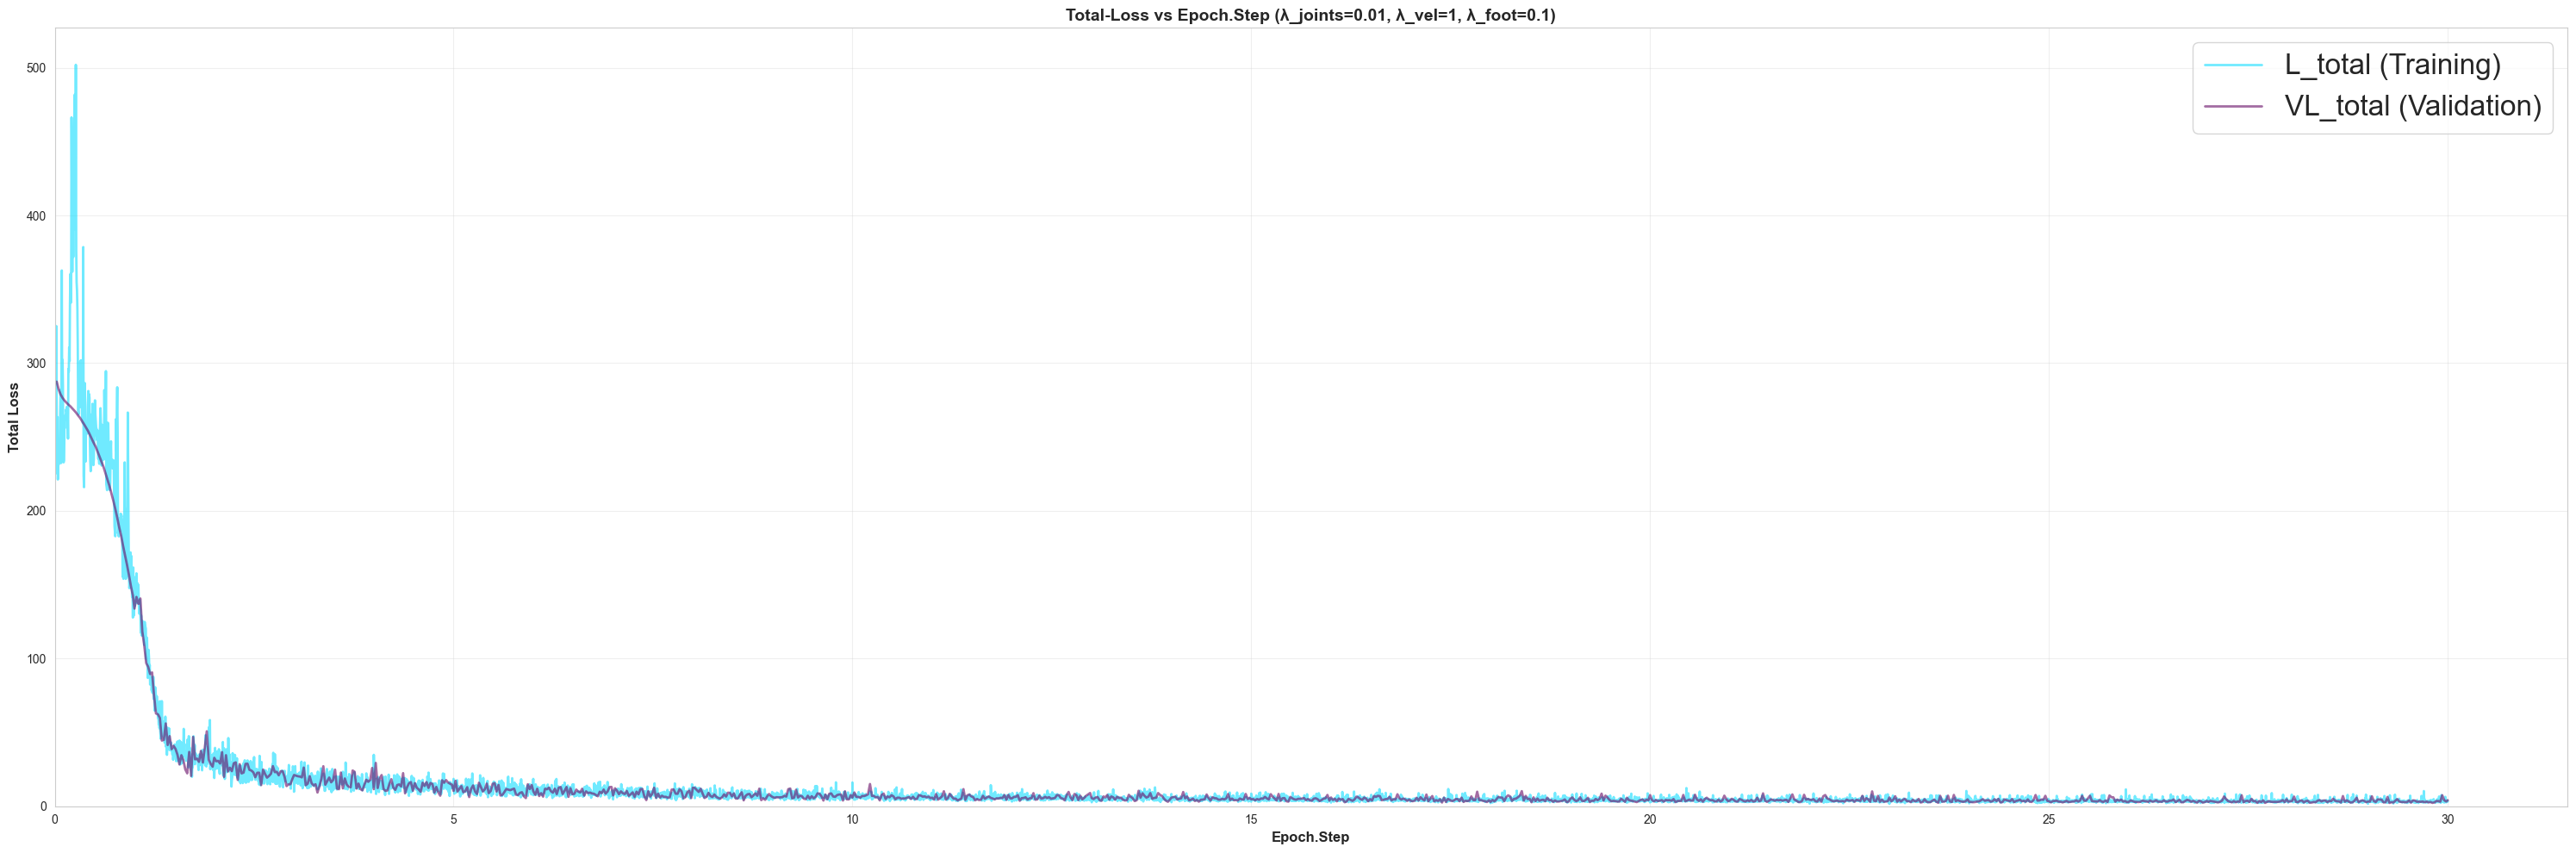

In [6]:
# Plot L_total and VL_total vs epoch.step
plt.figure(figsize=(30, 10))

# Plot training loss
plt.plot(df_clean['epoch_step_numeric'], df_clean['L_total'], 
         label=f'L_total (Training)', color=colors[0], linewidth=2, alpha=0.6)

# Plot validation loss (drop NaN values for plotting)
valid_mask = df_clean['VL_total'].notna()
plt.plot(df_clean.loc[valid_mask, 'epoch_step_numeric'], 
         df_clean.loc[valid_mask, 'VL_total'], 
         label=f'VL_total (Validation)', color=colors[1], linewidth=2, alpha=0.6)

plt.xlabel('Epoch.Step', fontsize=12, fontweight='bold')
plt.ylabel('Total Loss', fontsize=12, fontweight='bold')
plt.title(f'Total-Loss vs Epoch.Step ({lambda_values})', fontsize=14, fontweight='bold')
plt.legend(fontsize=24)
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.savefig(PLOT_DIR/(plt.gca().get_title()+'.png'))
plt.show()

#### Individual Losses [L_simple, L_joints, L_vel, L_foot] vs epoch.step

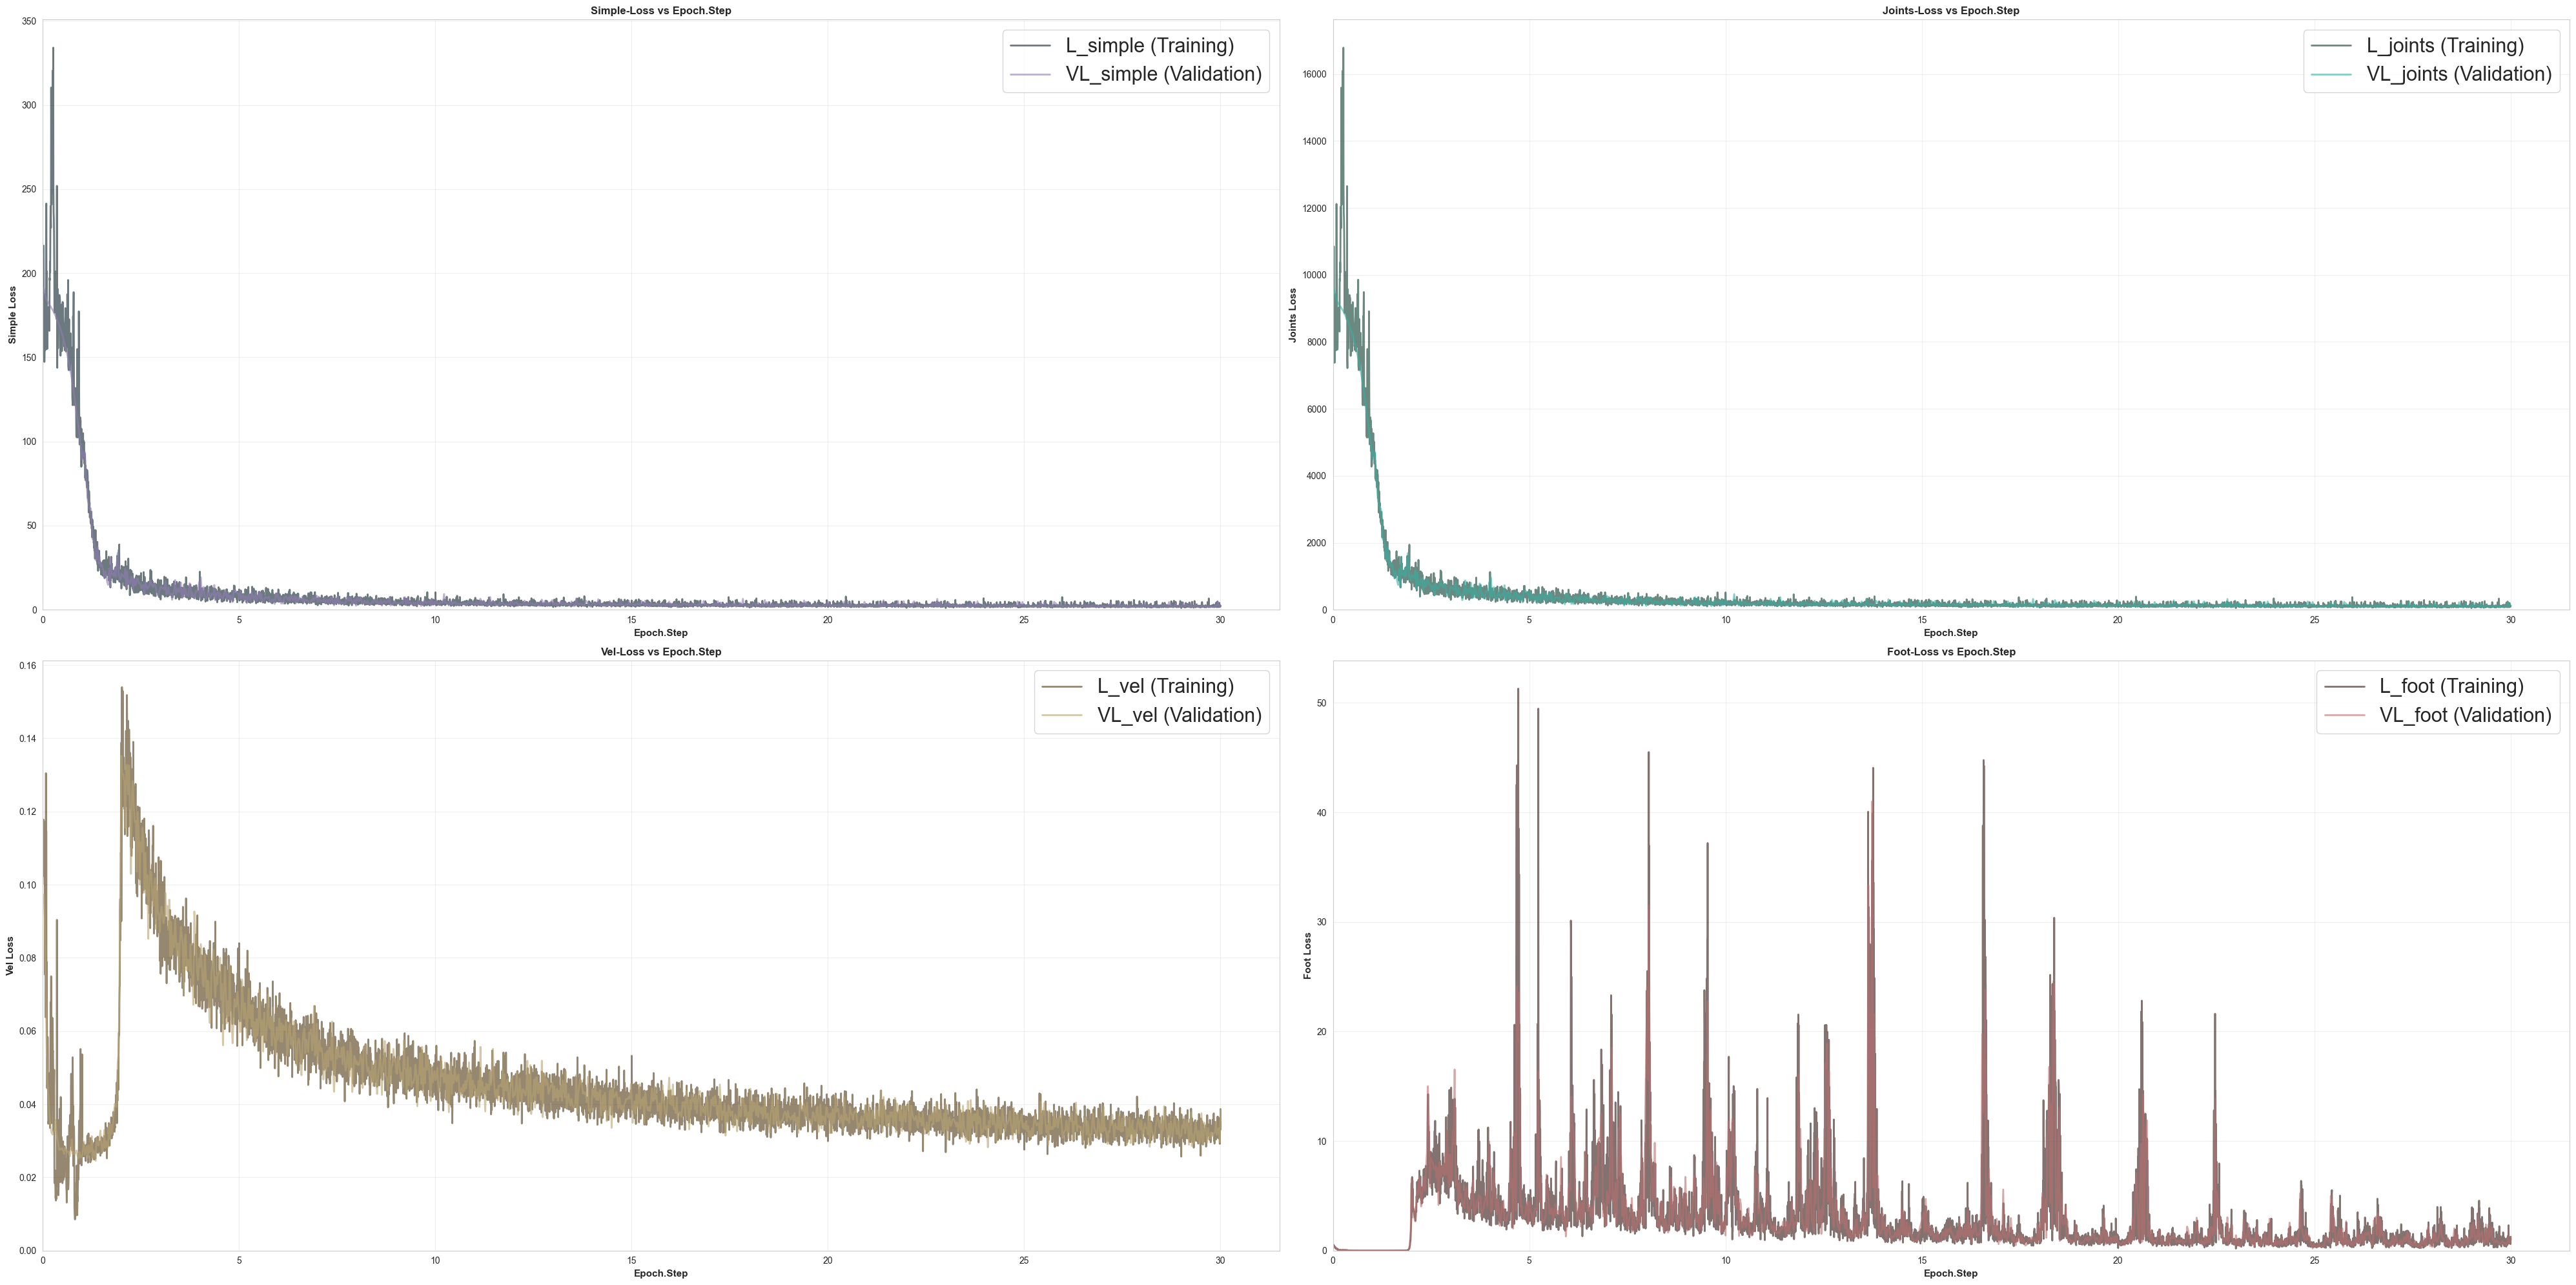

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(40, 20))
axes = axes.flatten()

for idx, component in enumerate(loss_components):
	ax = axes[idx]

	l_col = f'L_{component}'
	vl_col = f'VL_{component}'

	# Plot training loss
	ax.plot(df_clean['epoch_step_numeric'], df_clean[l_col], 
			label=f'{l_col} (Training)', color=colors_train[idx], 
			linewidth=2, alpha=0.6)

	# Plot validation loss
	valid_mask = df_clean[vl_col].notna()
	ax.plot(df_clean.loc[valid_mask, 'epoch_step_numeric'], 
			df_clean.loc[valid_mask, vl_col], 
			label=f'{vl_col} (Validation)', color=colors_val[idx], 
			linewidth=2, alpha=0.6)

	ax.set_xlabel('Epoch.Step', fontsize=11, fontweight='bold')
	ax.set_ylabel(f'{component.capitalize()} Loss', fontsize=11, fontweight='bold')
	ax.set_title(f'{component.capitalize()}-Loss vs Epoch.Step', 
					fontsize=12, fontweight='bold')
	ax.legend(fontsize=22)
	ax.grid(True, alpha=0.3)
	ax.set_xlim(left=0)
	ax.set_ylim(bottom=0)
	
plt.tight_layout()
plt.savefig(PLOT_DIR/f'{[comp.capitalize()for comp in loss_components]}-Loss vs Epoch.Step.png')
plt.show()


### Mean Losses vs Epoch

In [8]:
# Group by epoch and calculate mean
df_mean = df_clean.groupby('epoch').agg({
    'L_total': 'mean',
    'L_simple': 'mean',
    'L_joints': 'mean',
    'L_vel': 'mean',
    'L_foot': 'mean',
    'VL_total': 'mean',
    'VL_simple': 'mean',
    'VL_joints': 'mean',
    'VL_vel': 'mean',
    'VL_foot': 'mean'
}).reset_index()

print("Mean Loss per Epoch - Shape:", df_mean.shape)
print("\nFirst few rows:")
print(df_mean.head())


Mean Loss per Epoch - Shape: (30, 11)

First few rows:
   epoch     L_total    L_simple     L_joints     L_vel    L_foot    VL_total  \
0      1  252.139095  167.811366  8428.589251  0.037046  0.047961  230.371204   
1      2   58.424538   38.873103  1950.548700  0.034777  0.111723   55.600193   
2      3   23.723173   15.449278   747.605167  0.111362  6.864807   23.509325   
3      4   17.194998   11.081444   546.679471  0.083069  5.636902   16.978584   
4      5   13.994252    8.910254   439.537092  0.071644  6.169827   14.206641   

    VL_simple    VL_joints    VL_vel   VL_foot  
0  153.319973  7701.308689  0.034137  0.040119  
1   36.987202  1855.355536  0.036967  0.224687  
2   15.307902   740.407359  0.109423  6.879271  
3   10.943592   539.725788  0.083805  5.539304  
4    9.086936   448.400944  0.070845  5.648498  


#### Mean Total Loss vs Epoch

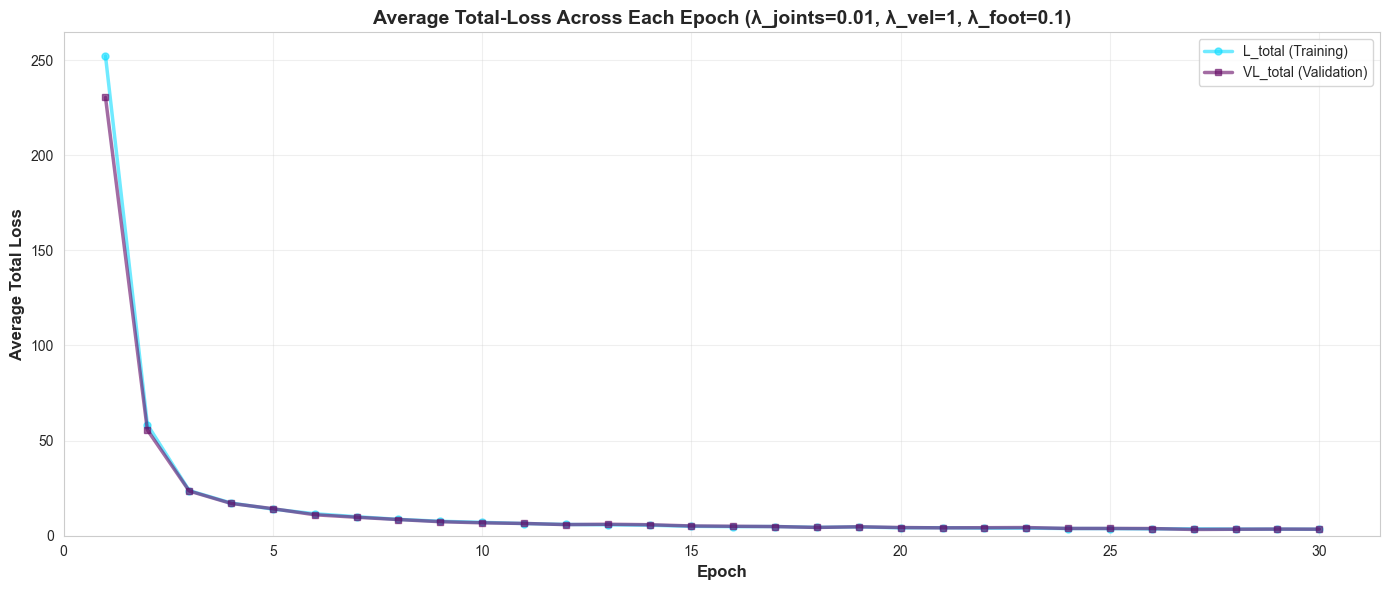

In [9]:
plt.figure(figsize=(14, 6))

# Plot training loss
plt.plot(df_mean['epoch'], df_mean['L_total'], 
         label='L_total (Training)', color=colors[0], 
         linewidth=2.5, marker='o', markersize=5, alpha=0.6)

# Plot validation loss
valid_mask = df_mean['VL_total'].notna()
plt.plot(df_mean.loc[valid_mask, 'epoch'], 
         df_mean.loc[valid_mask, 'VL_total'], 
         label='VL_total (Validation)', color=colors[1], 
         linewidth=2.5, marker='s', markersize=5, alpha=0.6)

plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Average Total Loss', fontsize=12, fontweight='bold')
plt.title(f'Average Total-Loss Across Each Epoch ({lambda_values})', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.savefig(PLOT_DIR/(plt.gca().get_title()+'.png'))
plt.show()

#### Mean Individual Losses [L_simple, L_joints, L_vel, L_foot] vs Epoch

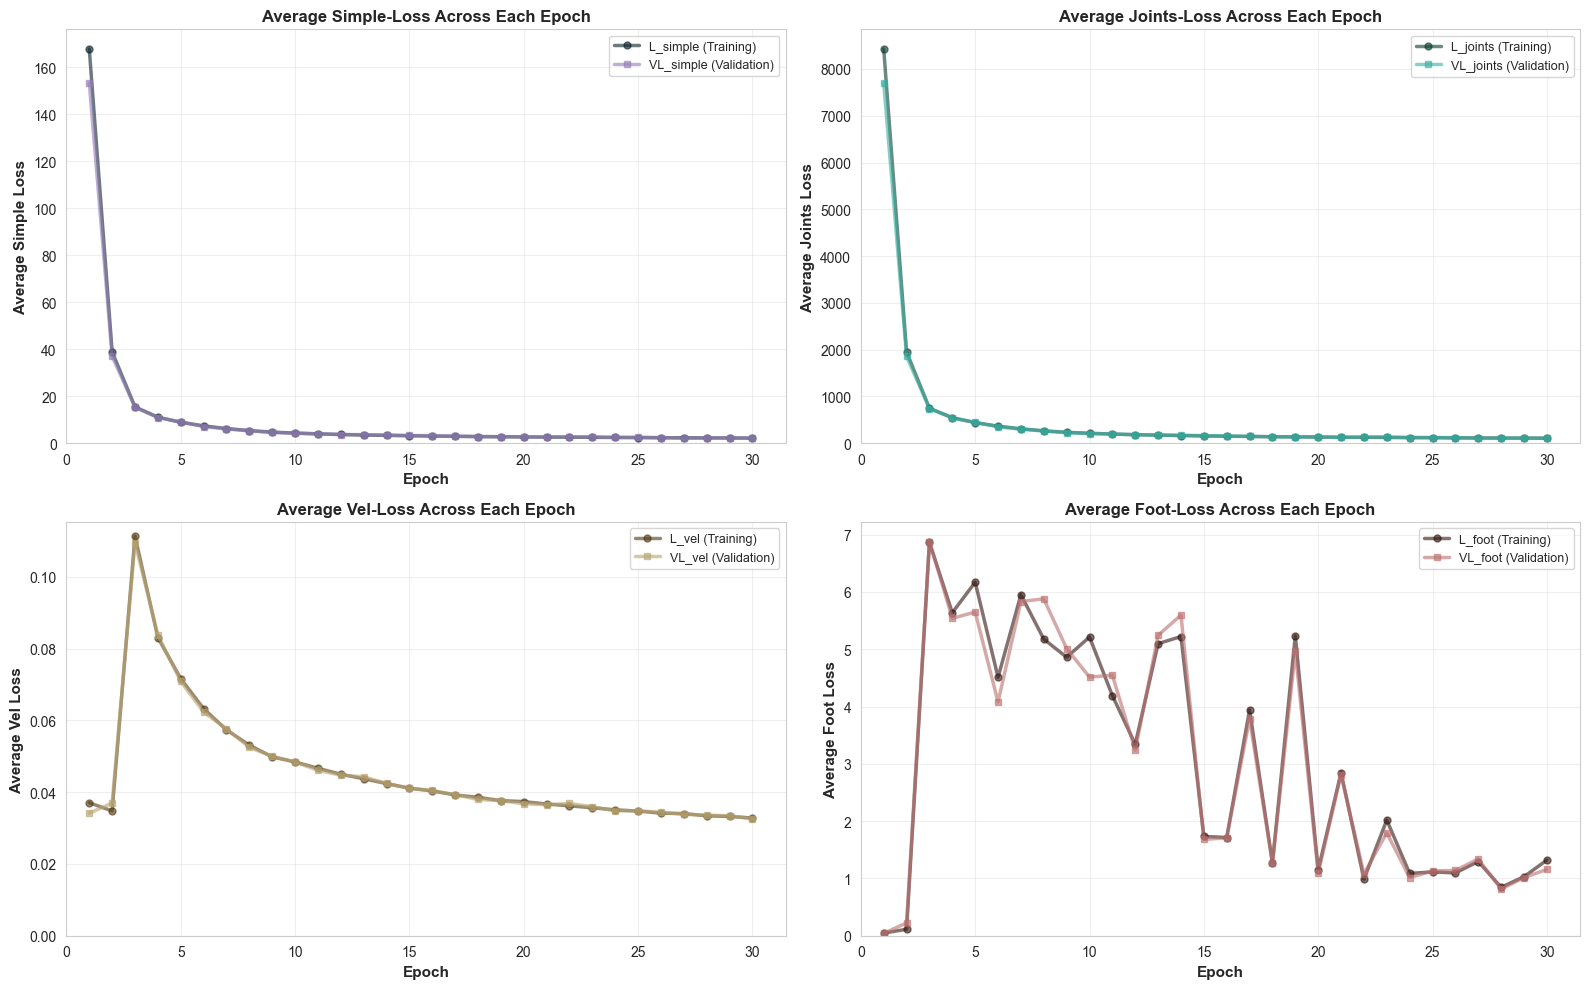

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, component in enumerate(loss_components):
	ax = axes[idx]

	l_col = f'L_{component}'
	vl_col = f'VL_{component}'

	# Plot training loss
	ax.plot(df_mean['epoch'], df_mean[l_col], 
			label=f'{l_col} (Training)', color=colors_train[idx], 
			linewidth=2.5, marker='o', markersize=5, alpha=0.6)

	# Plot validation loss
	valid_mask = df_mean[vl_col].notna()
	ax.plot(df_mean.loc[valid_mask, 'epoch'], 
			df_mean.loc[valid_mask, vl_col], 
			label=f'{vl_col} (Validation)', color=colors_val[idx], 
			linewidth=2.5, marker='s', markersize=5, alpha=0.6)

	ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
	ax.set_ylabel(f'Average {component.capitalize()} Loss', fontsize=11, fontweight='bold')
	ax.set_title(f'Average {component.capitalize()}-Loss Across Each Epoch', 
					fontsize=12, fontweight='bold')
	ax.legend(fontsize=9)
	ax.grid(True, alpha=0.3)
	ax.set_xlim(left=0)
	ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(PLOT_DIR/f'Average {[comp.capitalize()for comp in loss_components]}-Loss Across Each Epoch.png')
plt.show()

### Last Step Losses vs Epoch (with min-loss highlighted)

In [11]:
# Group by epoch and take the last step (highest step value)
df_last = df_clean.loc[df_clean.groupby('epoch')['step'].idxmax()].copy()

print("Last Step per Epoch - Shape:", df_last.shape)
print("\nFirst few rows:")
print(df_last.head())


Last Step per Epoch - Shape: (30, 14)

First few rows:
      epoch   step     L_total   L_simple     L_joints     L_vel    L_foot  \
204       1  26130  135.225723  89.971664  4520.030762  0.053639  0.001220   
409       2  26130   19.020601  12.620606   601.033386  0.090041  2.996201   
614       3  26130    9.733002   6.075429   293.369232  0.075667  6.482138   
819       4  26130   34.739758  22.613605  1126.763916  0.082546  7.759658   
1024      5  26130   18.445642  12.045840   596.348816  0.084012  3.523011   

        VL_total  VL_simple    VL_joints    VL_vel   VL_foot epoch.step  \
204   133.772858  89.001335  4474.543457  0.026014  0.000827    1.26130   
409    32.721733  21.443251  1048.917969  0.135268  6.540337    2.26130   
614    21.069983  13.616373   671.802063  0.092144  6.434456    3.26130   
819    11.479602   7.215886   353.841522  0.077483  6.478184    4.26130   
1024   10.310752   6.568982   323.198608  0.064549  4.452339    5.26130   

      epoch_step_numeric 

#### Last Step Total Loss vs Epoch

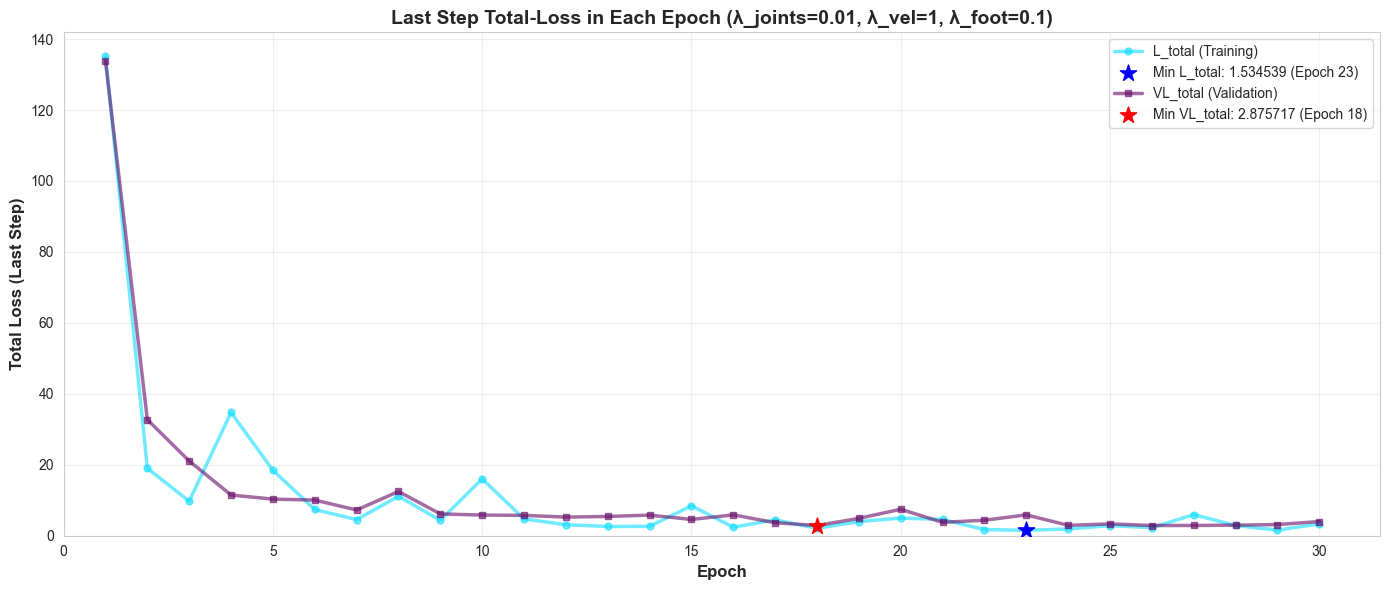

In [12]:
plt.figure(figsize=(14, 6))

# Plot training loss
plt.plot(df_last['epoch'], df_last['L_total'], 
         label='L_total (Training)', color=colors[0], 
         linewidth=2.5, marker='o', markersize=5, alpha=0.6)

# Find and highlight minimum training loss
min_train_idx = df_last['L_total'].idxmin()
min_train_epoch = df_last.loc[min_train_idx, 'epoch']
min_train_loss = df_last.loc[min_train_idx, 'L_total']
plt.scatter(min_train_epoch, min_train_loss, color='blue', s=150, 
            marker='*', zorder=5, label=f'Min L_total: {min_train_loss:.6f} (Epoch {min_train_epoch})')

# Plot validation loss
valid_mask = df_last['VL_total'].notna()
plt.plot(df_last.loc[valid_mask, 'epoch'], 
         df_last.loc[valid_mask, 'VL_total'], 
         label='VL_total (Validation)', color=colors[1], 
         linewidth=2.5, marker='s', markersize=5, alpha=0.6)

# Find and highlight minimum validation loss
if valid_mask.any():
    min_val_idx = df_last.loc[valid_mask, 'VL_total'].idxmin()
    min_val_epoch = df_last.loc[min_val_idx, 'epoch']
    min_val_loss = df_last.loc[min_val_idx, 'VL_total']
    plt.scatter(min_val_epoch, min_val_loss, color='red', s=150, 
                marker='*', zorder=5, label=f'Min VL_total: {min_val_loss:.6f} (Epoch {min_val_epoch})')

plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Total Loss (Last Step)', fontsize=12, fontweight='bold')
plt.title(f'Last Step Total-Loss in Each Epoch ({lambda_values})', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.savefig(PLOT_DIR/(plt.gca().get_title()+'.png'))
plt.show()

#### Last Step Individual Losses [L_simple, L_joints, L_vel, L_foot] vs Epoch

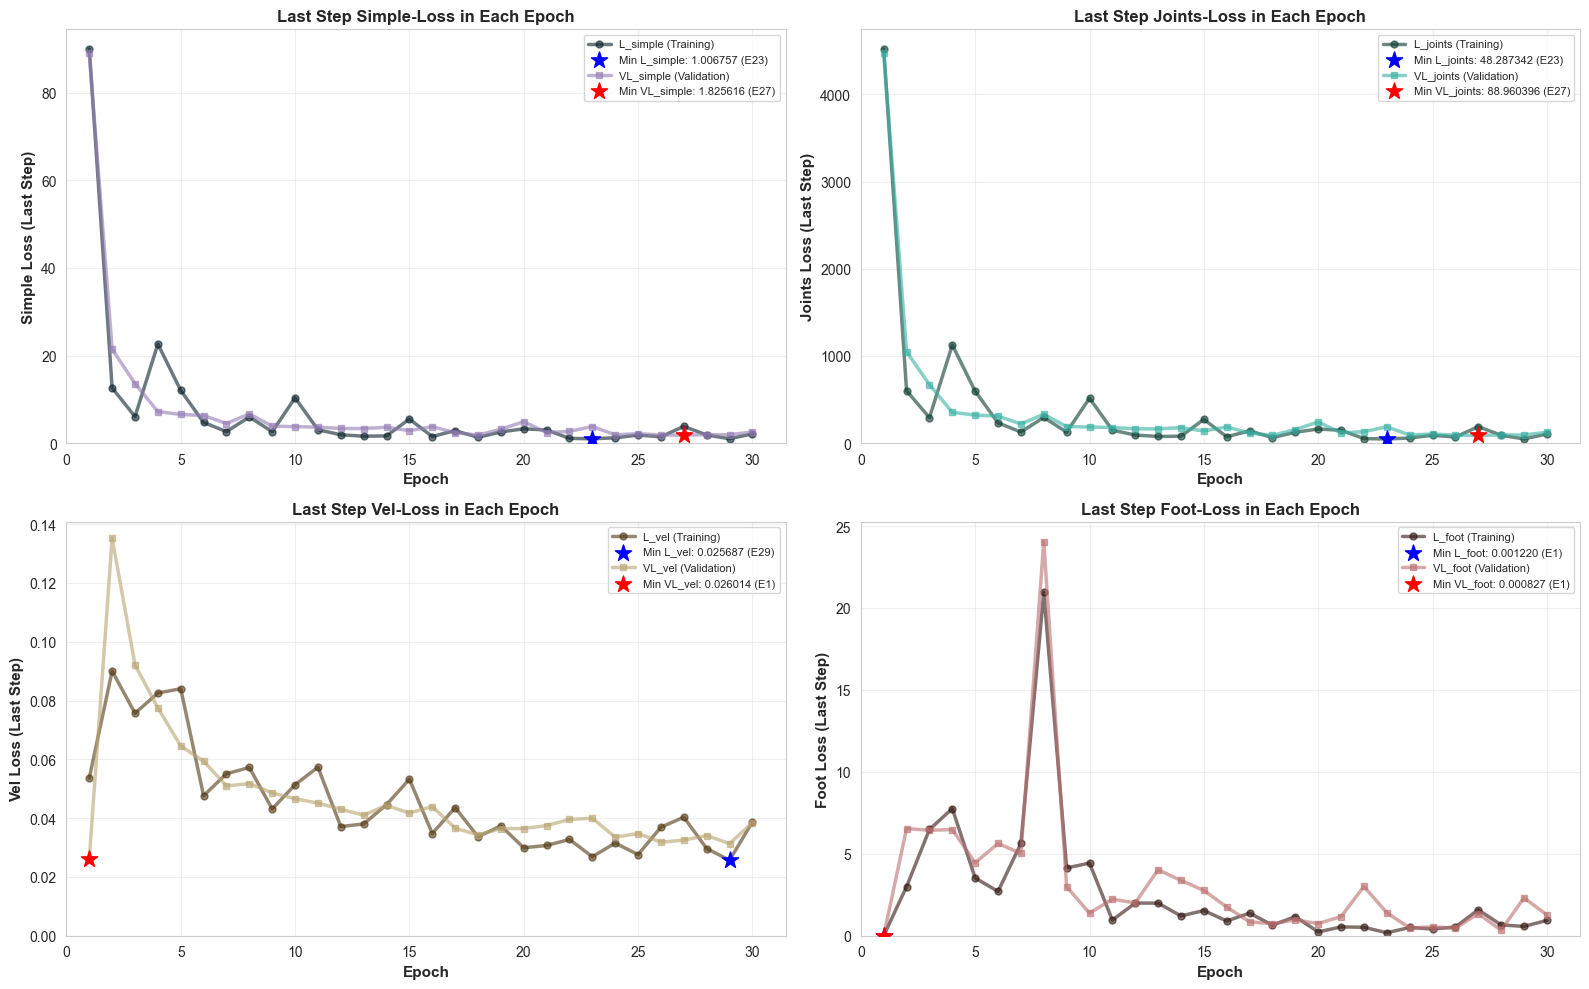

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, component in enumerate(loss_components):
	ax = axes[idx]

	l_col = f'L_{component}'
	vl_col = f'VL_{component}'

	# Plot training loss
	ax.plot(df_last['epoch'], df_last[l_col], 
			label=f'{l_col} (Training)', color=colors_train[idx], 
			linewidth=2.5, marker='o', markersize=5, alpha=0.6)

	# Find and highlight minimum training loss
	min_train_idx = df_last[l_col].idxmin()
	min_train_epoch = df_last.loc[min_train_idx, 'epoch']
	min_train_loss = df_last.loc[min_train_idx, l_col]
	ax.scatter(min_train_epoch, min_train_loss, color='blue', s=150, 
				marker='*', zorder=5, 
				label=f'Min {l_col}: {min_train_loss:.6f} (E{min_train_epoch})')

	# Plot validation loss
	valid_mask = df_last[vl_col].notna()
	if valid_mask.any():
		ax.plot(df_last.loc[valid_mask, 'epoch'], 
				df_last.loc[valid_mask, vl_col], 
				label=f'{vl_col} (Validation)', color=colors_val[idx], 
				linewidth=2.5, marker='s', markersize=5, alpha=0.6)
		
		# Find and highlight minimum validation loss
		min_val_idx = df_last.loc[valid_mask, vl_col].idxmin()
		min_val_epoch = df_last.loc[min_val_idx, 'epoch']
		min_val_loss = df_last.loc[min_val_idx, vl_col]
		ax.scatter(min_val_epoch, min_val_loss, color='red', s=150, 
					marker='*', zorder=5, 
					label=f'Min {vl_col}: {min_val_loss:.6f} (E{min_val_epoch})')

	ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
	ax.set_ylabel(f'{component.capitalize()} Loss (Last Step)', fontsize=11, fontweight='bold')
	ax.set_title(f'Last Step {component.capitalize()}-Loss in Each Epoch', 
					fontsize=12, fontweight='bold')
	ax.legend(fontsize=8)
	ax.grid(True, alpha=0.3)
	ax.set_xlim(left=0)
	ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(PLOT_DIR/f'Last Step {[comp.capitalize()for comp in loss_components]}-Loss in Each Epoch.png')
plt.show()


#### Summary Statistics

In [14]:
# Print summary statistics for the last step of each epoch
print("=" * 60)
print("SUMMARY STATISTICS - Last Step in Each Epoch")
print("=" * 60)

print("\nTraining Loss - Minimum Values:")
for component in ['total', 'simple', 'joints', 'vel', 'foot']:
    col = f'L_{component}'
    min_idx = df_last[col].idxmin()
    min_epoch = df_last.loc[min_idx, 'epoch']
    min_value = df_last.loc[min_idx, col]
    print(f"  {col:12s}: {min_value:.8f} at Epoch {min_epoch}")

print("\nValidation Loss - Minimum Values:")
for component in ['total', 'simple', 'joints', 'vel', 'foot']:
    col = f'VL_{component}'
    valid_data = df_last[df_last[col].notna()]
    if len(valid_data) > 0:
        min_idx = valid_data[col].idxmin()
        min_epoch = valid_data.loc[min_idx, 'epoch']
        min_value = valid_data.loc[min_idx, col]
        print(f"  {col:12s}: {min_value:.8f} at Epoch {min_epoch}")
    else:
        print(f"  {col:12s}: No valid data")


SUMMARY STATISTICS - Last Step in Each Epoch

Training Loss - Minimum Values:
  L_total     : 1.53453898 at Epoch 23
  L_simple    : 1.00675690 at Epoch 23
  L_joints    : 48.28734207 at Epoch 23
  L_vel       : 0.02568718 at Epoch 29
  L_foot      : 0.00122029 at Epoch 1

Validation Loss - Minimum Values:
  VL_total    : 2.87571740 at Epoch 18
  VL_simple   : 1.82561636 at Epoch 27
  VL_joints   : 88.96039581 at Epoch 27
  VL_vel      : 0.02601393 at Epoch 1
  VL_foot     : 0.00082668 at Epoch 1


---

## Qualitative Motion Visualizations

In [3]:
import os, glob, torch
from torch.utils.data import DataLoader

DATA_DIR = Path.cwd() / "datasets"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# >>> USER: set this to the folder containing your preprocessed .npz files
processed_data_dir = DATA_DIR / "AIST/processed" 

files = sorted(glob.glob(os.path.join(processed_data_dir, "*.npz")))
print("No. of Preprocessed data-files found:", len(files))

Device: cuda
No. of Preprocessed data-files found: 4355


In [4]:
ds = ViMoDataset(files, t_views=9) # all files loader
dl = DataLoader(ds, batch_size=1, shuffle=True, pin_memory=True)
it = iter(dl)

try:
	#best_epoch = df_last.loc[df_last['L_total'].idxmin(), 'epoch']
	best_epoch = 23
	model_path = MODEL_DIR / (get_model_file_name(model, "mini_", f"_epoch{best_epoch}") + "_ckpt.pth")
	ckpt = torch.load(model_path, map_location=device)
except Exception as e:
	print(f"WARNING: Couldn't fetch the epoch with minimum loss. Error: {e}")
	#last_epoch = df_last['epoch'][-1]
	last_epoch = 30
	model_path = MODEL_DIR / (get_model_file_name(model, "mini_", f"_epoch{last_epoch}") + "_ckpt.pth")
	ckpt = torch.load(model_path, map_location=device)

model.load_state_dict(ckpt['model_state'])
print("Loaded model checkpoint from", model_path)

Loaded model checkpoint from d:\STUDIES\MTech\#MTP\codes\vimo\models\mini_vimo(m151_p51_d128_h4_ml3_pl2_c25)_epoch23_ckpt.pth


In [6]:
batch = next(it)
T = model.max_T
make_beta_schedule(T, device=device)

model.to(device) # move to target device
m_gt = batch['m3d'].to(device)
p2d = batch['m3d'].to(device)

# Deterministic Sampling
t_minus_1 = torch.full((m_gt.shape[0],), T-1, dtype=torch.long, device=device) # t=T-1 (largest noise)
x_t = forward_diffusion_sample(m_gt, t_minus_1)
m_pe = reverse_denoising_sample(model, x_t, T, p2d) # final prediction estimate

# Stochastic Sampling
# m_pe = reverse_denoising_sample(model, m_gt.shape, T, p2d, stochasticity=True)



RuntimeError: mat1 and mat2 shapes cannot be multiplied (150x151 and 51x128)

In [ ]:
j3d_pos_gt = get_joint_positions(m_gt)
j3d_pos_pe = get_joint_positions(m_pe)

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define SMPL skeleton connections (24 joints)
smpl_connections = [
	(0, 1), (0, 2), (0, 3),  	# Pelvis(Root) to Hips, Spine
	(1, 4), (2, 5),          	# Hips to Knees
	(4, 7), (5, 8),          	# Knees to Ankles
	(7, 10), (8, 11),        	# Ankles to Foots
	(3, 6), (6, 9),          	# Spine to head
	(9, 12), (9, 13), (9, 14),  # Spine to Neck, Collars
	(12, 15),  					# Neck to Head
	(13, 16), (14, 17),			# Collars to Shoulders
	(16, 18), (17, 19),      	# Shoulders to Elbows
	(18, 20), (19, 21),      	# Elbows to Wrists
	(20, 22), (21, 23)       	# Wrists to Hands
]

def plot_skeleton_3d(joints_3d, title='3D Motion', save_path=None):
    """
    Plot 3D skeleton from joint positions
    joints_3d: (T, J, 3) array where T=frames, J=joints
    """
    fig = plt.figure(figsize=(12, 10))
    
    # Plot multiple frames (e.g., every 10th frame)
    n_frames = min(4, joints_3d.shape[0])
    frame_indices = np.linspace(0, joints_3d.shape[0]-1, n_frames, dtype=int)
    
    for idx, frame_idx in enumerate(frame_indices):
        ax = fig.add_subplot(2, 2, idx+1, projection='3d')
        
        joints = joints_3d[frame_idx]  # (J, 3)
        
        # Plot joints
        ax.scatter(joints[:, 0], joints[:, 1], joints[:, 2], 
                  c='red', s=50, alpha=0.8)
        
        # Plot skeleton connections
        for connection in smpl_connections:
            start_joint = joints[connection[0]]
            end_joint = joints[connection[1]]
            ax.plot([start_joint[0], end_joint[0]], 
                   [start_joint[1], end_joint[1]], 
                   [start_joint[2], end_joint[2]], 
                   'b-', linewidth=2, alpha=0.6)
        
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(f'Frame {frame_idx}', fontsize=12, fontweight='bold')
        
        # Set equal aspect ratio
        max_range = np.array([joints[:, 0].max()-joints[:, 0].min(),
                             joints[:, 1].max()-joints[:, 1].min(),
                             joints[:, 2].max()-joints[:, 2].min()]).max() / 2.0
        mid_x = (joints[:, 0].max()+joints[:, 0].min()) * 0.5
        mid_y = (joints[:, 1].max()+joints[:, 1].min()) * 0.5
        mid_z = (joints[:, 2].max()+joints[:, 2].min()) * 0.5
        ax.set_xlim(mid_x - max_range, mid_x + max_range)
        ax.set_ylim(mid_y - max_range, mid_y + max_range)
        ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Example usage 
plot_skeleton_3d(j3d_pos_gt, title='3D Motion Ground Truth')
plot_skeleton_3d(j3d_pos_pe, title='3D Motion Ground Truth')

In [ ]:
def plot_comparison_sequences(gt_motion, gen_motion, frame_indices=[0, 30, 60, 90], 
                              save_path=None):
    """
    Compare ground truth and generated motions side by side
    """
    fig = plt.figure(figsize=(20, 10))
    
    n_frames = len(frame_indices)
    
    for idx, frame_idx in enumerate(frame_indices):
        # Ground truth
        ax1 = fig.add_subplot(2, n_frames, idx+1, projection='3d')
        joints_gt = gt_motion[frame_idx]
        
        ax1.scatter(joints_gt[:, 0], joints_gt[:, 1], joints_gt[:, 2], 
                   c='green', s=50, alpha=0.8, label='GT')
        
        for connection in smpl_connections:
            start = joints_gt[connection[0]]
            end = joints_gt[connection[1]]
            ax1.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]], 
                    'g-', linewidth=2, alpha=0.6)
        
        ax1.set_title(f'GT - Frame {frame_idx}', fontsize=11, fontweight='bold')
        ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
        
        # Generated
        ax2 = fig.add_subplot(2, n_frames, n_frames+idx+1, projection='3d')
        joints_gen = gen_motion[frame_idx]
        
        ax2.scatter(joints_gen[:, 0], joints_gen[:, 1], joints_gen[:, 2], 
                   c='red', s=50, alpha=0.8, label='Generated')
        
        for connection in smpl_connections:
            start = joints_gen[connection[0]]
            end = joints_gen[connection[1]]
            ax2.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]], 
                    'r-', linewidth=2, alpha=0.6)
        
        ax2.set_title(f'Generated - Frame {frame_idx}', fontsize=11, fontweight='bold')
        ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
    
    plt.suptitle('Ground Truth vs Generated Motion Comparison', 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Example usage 
plot_comparison_sequences(generated_motion, title='Test 3D Motion GT')

In [ ]:
def plot_trajectory_comparison(gt_motion, gen_motion, joint_idx=0, save_path=None):
    """
    Plot 3D trajectory of specific joint (e.g., root joint)
    """
    fig = plt.figure(figsize=(14, 6))
    
    # 3D trajectory
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    
    gt_traj = gt_motion[:, joint_idx, :]
    gen_traj = gen_motion[:, joint_idx, :]
    
    ax1.plot(gt_traj[:, 0], gt_traj[:, 1], gt_traj[:, 2], 
            'g-', linewidth=2, alpha=0.8, label='Ground Truth')
    ax1.plot(gen_traj[:, 0], gen_traj[:, 1], gen_traj[:, 2], 
            'r--', linewidth=2, alpha=0.8, label='Generated')
    
    ax1.scatter(gt_traj[0, 0], gt_traj[0, 1], gt_traj[0, 2], 
               c='green', s=100, marker='o', label='GT Start')
    ax1.scatter(gen_traj[0, 0], gen_traj[0, 1], gen_traj[0, 2], 
               c='red', s=100, marker='o', label='Gen Start')
    
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
    ax1.set_title('3D Root Joint Trajectory', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2D projection (bird's eye view)
    ax2 = fig.add_subplot(1, 2, 2)
    
    ax2.plot(gt_traj[:, 0], gt_traj[:, 1], 'g-', linewidth=2, alpha=0.8, 
            label='Ground Truth')
    ax2.plot(gen_traj[:, 0], gen_traj[:, 1], 'r--', linewidth=2, alpha=0.8, 
            label='Generated')
    
    ax2.scatter(gt_traj[0, 0], gt_traj[0, 1], c='green', s=100, marker='o')
    ax2.scatter(gen_traj[0, 0], gen_traj[0, 1], c='red', s=100, marker='o')
    
    ax2.set_xlabel('X'); ax2.set_ylabel('Y')
    ax2.set_title('2D Trajectory (Top View)', fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axis('equal')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
def plot_motion_dynamics(gt_motion, gen_motion, save_path=None):
    """
    Visualize velocity and acceleration profiles
    """
    # Calculate velocities (frame-to-frame differences)
    gt_vel = np.linalg.norm(np.diff(gt_motion, axis=0), axis=-1)  # (T-1, J)
    gen_vel = np.linalg.norm(np.diff(gen_motion, axis=0), axis=-1)
    
    # Calculate accelerations
    gt_acc = np.linalg.norm(np.diff(gt_vel, axis=0), axis=-1)  # (T-2, J)
    gen_acc = np.linalg.norm(np.diff(gen_vel, axis=0), axis=-1)
    
    # Average across joints
    gt_vel_avg = gt_vel.mean(axis=1)
    gen_vel_avg = gen_vel.mean(axis=1)
    gt_acc_avg = gt_acc.mean(axis=1)
    gen_acc_avg = gen_acc.mean(axis=1)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Velocity plot
    axes[0].plot(gt_vel_avg, 'g-', linewidth=2, alpha=0.8, label='GT Velocity')
    axes[0].plot(gen_vel_avg, 'r--', linewidth=2, alpha=0.8, label='Gen Velocity')
    axes[0].set_xlabel('Frame', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Average Velocity', fontsize=12, fontweight='bold')
    axes[0].set_title('Motion Velocity Profile', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Acceleration plot
    axes[1].plot(gt_acc_avg, 'g-', linewidth=2, alpha=0.8, label='GT Acceleration')
    axes[1].plot(gen_acc_avg, 'r--', linewidth=2, alpha=0.8, label='Gen Acceleration')
    axes[1].set_xlabel('Frame', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Average Acceleration', fontsize=12, fontweight='bold')
    axes[1].set_title('Motion Acceleration Profile', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
def plot_foot_contact(motion, foot_contact_labels, save_path=None):
    """
    Visualize foot contact events
    foot_contact_labels: (T, 4) binary labels for [left_foot, left_toe, right_foot, right_toe]
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    frames = np.arange(len(foot_contact_labels))
    
    # Left foot contacts
    axes[0].fill_between(frames, 0, foot_contact_labels[:, 0], 
                         alpha=0.6, label='Left Foot', color='blue')
    axes[0].fill_between(frames, 0, foot_contact_labels[:, 1], 
                         alpha=0.4, label='Left Toe', color='lightblue')
    axes[0].set_ylabel('Contact', fontsize=12, fontweight='bold')
    axes[0].set_title('Left Foot Contact Events', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(-0.1, 1.1)
    
    # Right foot contacts
    axes[1].fill_between(frames, 0, foot_contact_labels[:, 2], 
                         alpha=0.6, label='Right Foot', color='red')
    axes[1].fill_between(frames, 0, foot_contact_labels[:, 3], 
                         alpha=0.4, label='Right Toe', color='lightcoral')
    axes[1].set_xlabel('Frame', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Contact', fontsize=12, fontweight='bold')
    axes[1].set_title('Right Foot Contact Events', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(-0.1, 1.1)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


## Advanced Visualization with Video Rendering

In [ ]:
# For actual video rendering, consider using:
# - pyrender (for high-quality 3D rendering)
# - trimesh (for mesh manipulation)
# - SMPL-X model for detailed human body

"""
Example workflow for video generation:
1. Load SMPL model parameters
2. For each frame, create SMPL mesh from theta parameters
3. Render mesh from camera viewpoint using pyrender
4. Save frames and compile into video using opencv or moviepy

Note: This requires SMPL model files and proper setup
Refer to: https://github.com/vchoutas/smplx for SMPL implementation
"""

def save_motion_video(motion_sequence, output_path='motion_video.mp4', fps=30):
    """
    Pseudo-code for saving motion as video
    Requires: pyrender, trimesh, smplx, opencv
    """
    import cv2
    # import pyrender
    # import trimesh
    # from smplx import SMPL
    
    # Initialize SMPL model
    # smpl = SMPL(model_path='path/to/smpl', gender='neutral')
    
    frames = []
    
    for frame_idx in range(len(motion_sequence)):
        # Get SMPL parameters for this frame
        # theta = motion_sequence[frame_idx]  # Pose parameters
        
        # Generate mesh
        # output = smpl(body_pose=theta[3:], global_orient=theta[:3])
        # vertices = output.vertices.detach().cpu().numpy()[0]
        # faces = smpl.faces
        
        # Render mesh
        # mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
        # scene = pyrender.Scene()
        # scene.add(pyrender.Mesh.from_trimesh(mesh))
        
        # Add camera and lighting
        # camera = pyrender.PerspectiveCamera(yfov=np.pi / 3.0)
        # light = pyrender.DirectionalLight(color=[1.0, 1.0, 1.0], intensity=3.0)
        
        # Render frame
        # renderer = pyrender.OffscreenRenderer(640, 480)
        # color, _ = renderer.render(scene)
        
        # frames.append(color)
        pass
    
    # Save video using opencv
    # fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    # out = cv2.VideoWriter(output_path, fourcc, fps, (640, 480))
    # for frame in frames:
    #     out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    # out.release()
    
    print(f"Video would be saved to: {output_path}")


## Error Analysis Visualizations

In [ ]:
def plot_joint_error_heatmap(gt_motion, gen_motion, joint_names=None, save_path=None):
    """
    Create heatmap showing per-joint errors over time
    """
    # Calculate per-joint per-frame errors
    errors = np.linalg.norm(gt_motion - gen_motion, axis=-1)  # (T, J)
    
    if joint_names is None:
        joint_names = [f'J{i}' for i in range(errors.shape[1])]
    
    fig, ax = plt.subplots(figsize=(16, 8))
    
    im = ax.imshow(errors.T, aspect='auto', cmap='hot', interpolation='nearest')
    
    ax.set_xlabel('Frame', fontsize=12, fontweight='bold')
    ax.set_ylabel('Joint', fontsize=12, fontweight='bold')
    ax.set_title('Per-Joint Position Error Over Time', fontsize=14, fontweight='bold')
    ax.set_yticks(np.arange(len(joint_names)))
    ax.set_yticklabels(joint_names, fontsize=8)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Position Error (units)', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print statistics
    print(f"\nError Statistics:")
    print(f"Mean error: {errors.mean():.4f}")
    print(f"Std error: {errors.std():.4f}")
    print(f"Max error: {errors.max():.4f}")
    print(f"\nMost problematic joints:")
    joint_errors = errors.mean(axis=0)
    worst_joints = np.argsort(joint_errors)[-5:][::-1]
    for idx in worst_joints:
        print(f"  {joint_names[idx]}: {joint_errors[idx]:.4f}")


In [ ]:
def plot_distribution_comparison(gt_motion, gen_motion, save_path=None):
    """
    Compare statistical distributions of GT vs Generated motions
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Joint position distributions
    gt_flat = gt_motion.reshape(-1, 3)
    gen_flat = gen_motion.reshape(-1, 3)
    
    for idx, (ax, coord, label) in enumerate(zip(axes[0], 
                                                  [0, 1, 2], 
                                                  ['X', 'Y', 'Z'])):
        ax.hist(gt_flat[:, coord], bins=50, alpha=0.6, label='GT', 
               color='green', density=True)
        ax.hist(gen_flat[:, coord], bins=50, alpha=0.6, label='Generated', 
               color='red', density=True)
        ax.set_xlabel(f'{label} Coordinate', fontsize=11, fontweight='bold')
        ax.set_ylabel('Density', fontsize=11, fontweight='bold')
        ax.set_title(f'{label}-axis Position Distribution', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Velocity distributions
    gt_vel = np.linalg.norm(np.diff(gt_motion, axis=0), axis=-1).flatten()
    gen_vel = np.linalg.norm(np.diff(gen_motion, axis=0), axis=-1).flatten()
    
    axes[1, 0].hist(gt_vel, bins=50, alpha=0.6, label='GT', 
                   color='green', density=True)
    axes[1, 0].hist(gen_vel, bins=50, alpha=0.6, label='Generated', 
                   color='red', density=True)
    axes[1, 0].set_xlabel('Velocity Magnitude', fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel('Density', fontsize=11, fontweight='bold')
    axes[1, 0].set_title('Velocity Distribution', fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Acceleration distributions
    gt_acc = np.diff(gt_vel)
    gen_acc = np.diff(gen_vel)
    
    axes[1, 1].hist(gt_acc, bins=50, alpha=0.6, label='GT', 
                   color='green', density=True)
    axes[1, 1].hist(gen_acc, bins=50, alpha=0.6, label='Generated', 
                   color='red', density=True)
    axes[1, 1].set_xlabel('Acceleration', fontsize=11, fontweight='bold')
    axes[1, 1].set_ylabel('Density', fontsize=11, fontweight='bold')
    axes[1, 1].set_title('Acceleration Distribution', fontsize=12, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Q-Q plot for normality check
    from scipy import stats
    
    stats.probplot(gt_vel, dist="norm", plot=axes[1, 2])
    axes[1, 2].get_lines()[0].set_color('green')
    axes[1, 2].get_lines()[0].set_label('GT')
    
    stats.probplot(gen_vel, dist="norm", plot=axes[1, 2])
    axes[1, 2].get_lines()[2].set_color('red')
    axes[1, 2].get_lines()[2].set_label('Generated')
    
    axes[1, 2].set_title('Q-Q Plot (Velocity)', fontsize=12, fontweight='bold')
    axes[1, 2].legend()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
